In [1]:
"""Calculate radial displacements around muon and plot against distance from it.

Copyright of MuFinder:

https://gitlab.com/BenHuddart/mufinder/-/blob/master/src/mufinder/core/clustering/displacements.py?ref_type=heads

""" 
import ase 
import numpy as np 
from ase.build.supercells import make_supercell 
from ase.data.colors import jmol_colors 
from ase.geometry import find_mic, get_distances 
from ase.symbols import symbols2numbers 
from matplotlib import pyplot as plt 
from matplotlib.lines import Line2D 
from scipy.optimize import linear_sum_assignment

In [2]:
def make_supercell_like(input_struct: ase.Atoms, target_struct: ase.Atoms) -> ase.Atoms:
    """Make a supercell of `input_struct` to match `target_struct`."""
    # combined_cell = target_struct.get_cell() @ np.linalg.inv(input_struct.get_cell())
    combined_cell = np.dot(target_struct.get_cell(), np.linalg.inv(input_struct.get_cell()))

    combined_cell_int = np.round(combined_cell).astype(int)

    output_struct = make_supercell(input_struct, combined_cell_int)
    return output_struct


def projected_distance(a: np.ndarray, b: np.ndarray, axis: int = 1) -> np.ndarray:
    """Projected length of the first vector along the second."""
    return (a * b).sum(axis=axis) / np.linalg.norm(b, axis=axis)


def displacement_matrix(
    initial_struct: ase.Atoms,
    final_struct: ase.Atoms,
    fill_value: float = np.inf,
) -> np.ndarray[tuple[int, int], np.dtype[np.float64]]:
    """Calculate distance between atoms of the same species.

    - `input_struct` is the initial structure before relaxation.
    - `final_struct` is the relaxed structure after geometry optimisation.
    - `fill_value` is the distance value to use for unmatched atoms.

    Returns a matrix of distances between matching atoms.
    """
    output = np.full((len(initial_struct), len(final_struct)), fill_value)

    initial_symbols = initial_struct.get_chemical_symbols()
    final_symbols = final_struct.get_chemical_symbols()

    symbols = set(initial_symbols) | set(final_symbols)

    for sym in symbols:
        initial_ind = np.char.equal(initial_symbols, sym)
        initial_positions = initial_struct.positions[initial_ind]

        final_ind = np.char.equal(final_symbols, sym)
        final_positions = final_struct.positions[final_ind]

        if initial_positions.size == 0 or final_positions.size == 0:
            continue

        _, D = get_distances(
            initial_positions, final_positions, cell=initial_struct.cell, pbc=True
        )

        output[np.ix_(initial_ind, final_ind)] = D

    return output


def _match_atoms(
    input_struct: ase.Atoms, final_struct: ase.Atoms
) -> tuple[ase.Atoms, np.ndarray, np.ndarray]:
    """Build the initial supercell and the optimal atom-to-atom assignment.

    Returns the initial structure (as a supercell matching `final_struct`),
    `row_ind` (indices into the initial structure) and `col_ind` (indices
    into `final_struct`) such that `row_ind[i]` and `col_ind[i]` refer to
    the same physical atom before and after relaxation.
    """
    initial_struct = make_supercell_like(input_struct, final_struct)

    displ_mat = displacement_matrix(initial_struct, final_struct)
    row_ind, col_ind = linear_sum_assignment(displ_mat)

    return initial_struct, row_ind, col_ind


def _muon_position(final_struct: ase.Atoms, muon_label: str) -> np.ndarray:
    """Get the position(s) of the muon in the (relaxed) final structure."""
    muon_ind = final_struct.get_atomic_numbers() == symbols2numbers(muon_label)
    return final_struct.positions[muon_ind]


def _min_muon_distance(
    muon_position: np.ndarray,
    positions: np.ndarray,
    cell: ase.cell.Cell,
    order_ind: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Vector/distance from the muon to `positions`, matched via `order_ind`.

    - `muon_position` is one (or more) muon site(s) in the final structure.
    - `positions` is the set of atomic positions to measure to (either the
      unperturbed initial-lattice positions, or the perturbed/relaxed
      positions).
    - `order_ind` maps each output entry to the correct row in `positions`
      (this is `row_ind` for initial/unperturbed positions, or `col_ind`
      for final/perturbed positions).

    If there is more than one muon site, the minimum distance over all
    muon sites is taken for each atom (matching the original behaviour).

    Returns the displacement vector and distance from muon to atom, one
    per entry of `order_ind`.
    """
    vectors, distances = get_distances(muon_position, positions, cell=cell, pbc=True)

    reordered_distances = distances[:, order_ind]
    min_ind = reordered_distances.argmin(axis=0)

    dist = np.take_along_axis(reordered_distances, min_ind[None, :], 0).ravel()
    vec = vectors[min_ind, order_ind]

    return vec, dist


def calculate_radial_displacement_old(
    input_struct: ase.Atoms, final_struct: ase.Atoms, muon_label: str
) -> tuple[
    list[str],
    np.ndarray[tuple[int], np.dtype[np.float64]],
    np.ndarray[tuple[int], np.dtype[np.float64]],
]:
    """Calculate the radial displacement around muon between structures.

    - `input_struct` is the initial structure before relaxation.
    - `final_struct` is the relaxed structure after geometry optimisation.
    - `muon_label` is the species label used for the muon.

    Returns the chemical symbols, distance to muon and radial displacement.
    """
    initial_struct = make_supercell_like(input_struct, final_struct)

    # Calculate distances between atoms of same species
    displ_mat = displacement_matrix(initial_struct, final_struct)
    # Assign atoms between two structures to minimize displacement
    row_ind, col_ind = linear_sum_assignment(displ_mat)

    # Calculate vectors and distances from atoms to muon
    muon_ind = final_struct.get_atomic_numbers() == symbols2numbers(muon_label)
    muon_position = final_struct.positions[muon_ind]
    muon_vectors, muon_distances = get_distances(
        muon_position, initial_struct.positions, cell=initial_struct.cell, pbc=True
    )

    # Reorder distances using linear sum assignment
    muon_distances = muon_distances[:, row_ind]
    # Use minimal distance from muon to each atom
    muon_min_ind = muon_distances.argmin(axis=0)
    muon_dist = np.take_along_axis(muon_distances, muon_min_ind[None, :], 0).ravel()

    # Project atom displacement vector along vector between muon and atom
    atom_disp, _ = find_mic(
        final_struct.positions[col_ind] - initial_struct.positions[row_ind],
        initial_struct.cell,
        pbc=True,
    )
    muon_disp = muon_vectors[muon_min_ind, row_ind]
    radial_dist = projected_distance(atom_disp, muon_disp)

    symbols = initial_struct[row_ind].get_chemical_symbols()

    return symbols, muon_dist, radial_dist


def calculate_radial_displacement(
    input_struct: ase.Atoms, final_struct: ase.Atoms, muon_label: str
) -> tuple[
    list[str],
    np.ndarray[tuple[int], np.dtype[np.float64]],
    np.ndarray[tuple[int], np.dtype[np.float64]],
]:
    """Calculate the radial displacement around muon between structures.

    - `input_struct` is the initial structure before relaxation.
    - `final_struct` is the relaxed structure after geometry optimisation.
    - `muon_label` is the species label used for the muon.

    `muon_dist` here is the distance from the muon (in the relaxed
    structure) to each atom's UNPERTURBED (initial-lattice) position.
    See `calculate_radial_displacement_full` if you also need the
    perturbed (relaxed) muon distance.

    Returns the chemical symbols, distance to muon and radial displacement.
    """
    initial_struct, row_ind, col_ind = _match_atoms(input_struct, final_struct)

    muon_position = _muon_position(final_struct, muon_label)

    muon_disp, muon_dist = _min_muon_distance(
        muon_position, initial_struct.positions, initial_struct.cell, row_ind
    )

    # Project atom displacement vector along vector between muon and atom
    atom_disp, _ = find_mic(
        final_struct.positions[col_ind] - initial_struct.positions[row_ind],
        initial_struct.cell,
        pbc=True,
    )
    radial_dist = projected_distance(atom_disp, muon_disp)

    symbols = initial_struct[row_ind].get_chemical_symbols()

    return symbols, muon_dist, radial_dist


def calculate_radial_displacement_full(
    input_struct: ase.Atoms, final_struct: ase.Atoms, muon_label: str
) -> tuple[
    list[str],
    np.ndarray[tuple[int], np.dtype[np.float64]],
    np.ndarray[tuple[int], np.dtype[np.float64]],
    np.ndarray[tuple[int], np.dtype[np.float64]],
]:
    """Calculate radial displacement plus both perturbed and unperturbed
    distances from the muon, in one pass.

    - `input_struct` is the initial structure before relaxation.
    - `final_struct` is the relaxed structure after geometry optimisation.
    - `muon_label` is the species label used for the muon.

    All returned arrays are aligned to the same atom ordering (i.e.
    `symbols[i]`, `muon_dist_unperturbed[i]`, `muon_dist_perturbed[i]` and
    `radial_dist[i]` all refer to the same physical atom).

    Returns:
        symbols: chemical symbol of each matched atom.
        muon_dist_unperturbed: distance from muon to each atom's initial
            (unperturbed/unrelaxed) position.
        muon_dist_perturbed: distance from muon to each atom's final
            (perturbed/relaxed) position.
        radial_dist: radial displacement of each atom, projected along the
            muon -> atom (unperturbed) direction.
    """
    initial_struct, row_ind, col_ind = _match_atoms(input_struct, final_struct)

    muon_position = _muon_position(final_struct, muon_label)

    # Distance/vector from muon to each atom's UNPERTURBED (initial-lattice) position
    muon_vec_unperturbed, muon_dist_unperturbed = _min_muon_distance(
        muon_position, initial_struct.positions, initial_struct.cell, row_ind
    )

    # Distance from muon to each atom's PERTURBED (relaxed) position
    _, muon_dist_perturbed = _min_muon_distance(
        muon_position, final_struct.positions, final_struct.cell, col_ind
    )

    # Project atom displacement vector along vector between muon and atom
    atom_disp, _ = find_mic(
        final_struct.positions[col_ind] - initial_struct.positions[row_ind],
        initial_struct.cell,
        pbc=True,
    )
    radial_dist = projected_distance(atom_disp, muon_vec_unperturbed)

    symbols = initial_struct[row_ind].get_chemical_symbols()

    return symbols, muon_dist_unperturbed, muon_dist_perturbed, radial_dist


def radial_to_dict(
    input_struct: ase.Atoms, final_struct: ase.Atoms, muon_label: str
) -> dict[str, np.ndarray | list[str]]:
    """Run `calculate_radial_displacement_full` and return a single dict of arrays.
 
    - `input_struct` is the initial structure before relaxation.
    - `final_struct` is the relaxed structure after geometry optimisation.
    - `muon_label` is the species label used for the muon.
 
    Returns a single dict with keys:
        "symbols", "muon_dist_unperturbed", "muon_dist_perturbed", "radial_dist"
    where each value is a full array/list aligned by index (i.e. entry `i`
    of every value refers to the same physical atom). Useful for e.g.
    building a pandas DataFrame directly via `pd.DataFrame(result)`.
    """
    symbols, muon_dist_unperturbed, muon_dist_perturbed, radial_dist = (
        calculate_radial_displacement_full(input_struct, final_struct, muon_label)
    )
 
    return {
        "symbols": symbols,
        "muon_dist_unperturbed": muon_dist_unperturbed,
        "muon_dist_perturbed": muon_dist_perturbed,
        "radial_dist": radial_dist,
    }


def select_radial_displacement(
    radial_res: dict,
    species: str | list[str] | None = None,
    distance_type: str = "unperturbed",
    cutoff: float | None = None,
) -> dict[str, np.ndarray]:
    """Select a subset of atoms from `radial_to_dict`
    output, by species and by a distance-from-muon cutoff.
 
    Parameters
    ----------
    radial_res : dict
        Output of `radial_to_dict` (keys: "symbols", "muon_dist_unperturbed",
        "muon_dist_perturbed", "radial_dist").
    species : str, list of str, or None, default=None
        Chemical species to keep, e.g. 'V' or ['V', 'F']. None keeps all
        species (select all).
    distance_type : 'perturbed' or 'unperturbed', default='unperturbed'
        Which muon distance to use, both for applying `cutoff` and as the
        returned "distance" array (e.g. for plotting radial_dist vs distance).
    cutoff : float or None, default=None
        Keep only atoms whose selected distance is < cutoff. None applies
        no cutoff filtering (select all, subject only to `species`).
 
    Returns
    -------
    dict with keys:
        "symbols" : chemical symbol of each retained atom.
        "distance" : the muon_dist_unperturbed or muon_dist_perturbed
            array (per `distance_type`), for the retained atoms.
        "radial_dist" : radial displacement of the retained atoms.
        "indices" : indices into the original `radial_res` arrays of the
            retained atoms, in case you need to cross-reference something
            else (e.g. the other distance_type, or atom identities).
    """
    if distance_type not in ("perturbed", "unperturbed"):
        raise ValueError(
            f"distance_type must be 'perturbed' or 'unperturbed', got {distance_type!r}"
        )
 
    symbols = np.asarray(radial_res["symbols"])
    radial_dist = np.asarray(radial_res["radial_dist"])
    distance = np.asarray(radial_res[f"muon_dist_{distance_type}"])
 
    if species is None:
        species_mask = np.ones(len(symbols), dtype=bool)
    else:
        if isinstance(species, str):
            species = (species,)
        species_mask = np.isin(symbols, species)
 
    cutoff_mask = np.ones(len(symbols), dtype=bool) if cutoff is None else distance < cutoff
 
    keep = species_mask & cutoff_mask
    indices = np.nonzero(keep)[0]
 
    return {
        "symbols": symbols[keep],
        "distance": distance[keep],
        "displacements": radial_dist[keep],
        "indices": indices,
    }


def plot_radial_displacement_old(
    input_struct: ase.Atoms, structure: ase.Atoms, muon_label: str
):
    """Make a `matplotlib` figure showing radial displacement against distance to the muon.

    - `input_struct` is the initial structure before relaxation.
    - `final_struct` is the relaxed structure after geometry optimisation.
    - `muon_label` is the species label used for the muon.

    """
    symbols, muon_dist, radial_dist = calculate_radial_displacement(
        input_struct, structure, muon_label
    )

    symbol_colors = np.array([jmol_colors[symbols2numbers(sym)] for sym in symbols])

    legend_labels = sorted(set(symbols), key=symbols2numbers)
    legend_colors = [jmol_colors[symbols2numbers(sym)] for sym in legend_labels]

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=label,
            markerfacecolor=color,
            markeredgecolor="black",
        )
        for label, color in zip(legend_labels, legend_colors)
    ]

    plt.figure()
    plt.scatter(muon_dist, radial_dist, c=symbol_colors, edgecolor="black")
    plt.ylabel("Radial displacement (Å)")
    plt.xlabel("Distance from muon site (Å)")
    plt.legend(handles=legend_elements)

    plt.show()


def plot_radial_displacement(
    input_struct: ase.Atoms,
    structure: ase.Atoms,
    muon_label: str,
    use_perturbed: bool = False,
):
    """Make a `matplotlib` figure showing radial displacement against distance to the muon.

    - `input_struct` is the initial structure before relaxation.
    - `structure` is the relaxed structure after geometry optimisation.
    - `muon_label` is the species label used for the muon.
    - `use_perturbed` if True, plot against the perturbed (relaxed) muon
      distance instead of the unperturbed (initial-lattice) muon distance.
    """
    symbols, muon_dist_unperturbed, muon_dist_perturbed, radial_dist = (
        calculate_radial_displacement_full(input_struct, structure, muon_label)
    )

    muon_dist = muon_dist_perturbed if use_perturbed else muon_dist_unperturbed

    symbol_colors = np.array([jmol_colors[symbols2numbers(sym)] for sym in symbols])

    legend_labels = sorted(set(symbols), key=symbols2numbers)
    legend_colors = [jmol_colors[symbols2numbers(sym)] for sym in legend_labels]

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=label,
            markerfacecolor=color,
            markeredgecolor="black",
        )
        for label, color in zip(legend_labels, legend_colors)
    ]

    plt.figure()
    plt.scatter(muon_dist, radial_dist, c=symbol_colors, edgecolor="black")
    plt.ylabel("Radial displacement (Å)")
    plt.xlabel("Distance from muon site (Å)")
    plt.legend(handles=legend_elements)

    plt.show()
    


def max_displacement_old(input_struct: ase.Atoms, final_struct: ase.Atoms) -> float:
    """Calculate maximum displacement between atoms in two structures."""
    initial_struct = make_supercell_like(input_struct, final_struct)

    displ_mat = displacement_matrix(initial_struct, final_struct)
    row_ind, col_ind = linear_sum_assignment(displ_mat)

    return np.max(displ_mat[row_ind, col_ind])


def max_displacement(input_struct: ase.Atoms, final_struct: ase.Atoms) -> float:
    """Calculate maximum displacement between atoms in two structures."""
    initial_struct, row_ind, col_ind = _match_atoms(input_struct, final_struct)
    displ_mat = displacement_matrix(initial_struct, final_struct)

    return np.max(displ_mat[row_ind, col_ind])

In [3]:
# import sys
# from pathlib import Path
# ROOT = Path.cwd().parent

# if str(ROOT) not in sys.path:
#     sys.path.insert(0, str(ROOT)) 

# import constants
import numpy as np
from constants import constants
from io_tools.read import read_cif
from io_tools.read_ase import read_from_file

In [4]:
import os
import matplotlib.pyplot as plt
dpath='/home/misah/projects/muonscripts/DATA'

In [5]:
file = 'V3Si_QE_RELAX3x3x3_SITE_A.IN'
file = os.path.join(dpath, file)
input_struct = read_from_file(file, format="espresso-in")

file = 'V3Si_QE_RELAX3x3x3_SITE_A.OUT'
file = os.path.join(dpath, file)
final_struct = read_from_file(file, format="espresso-out", index=-1)

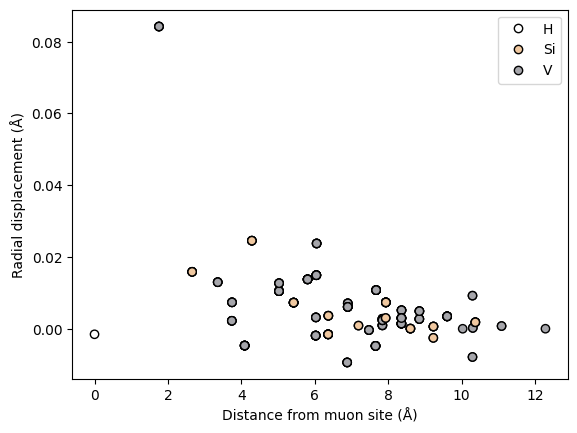

In [6]:
plot_radial_displacement(
    input_struct,
    structure=final_struct,
    muon_label='H',
    use_perturbed=True,
)

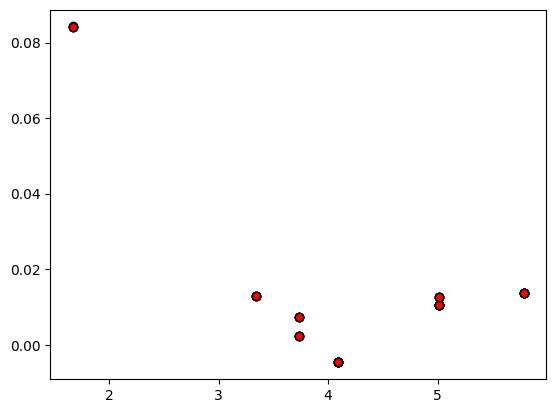

In [7]:
radial_res = radial_to_dict(input_struct, final_struct, muon_label='H')

sel = select_radial_displacement(
    radial_res,
    species='V',
    distance_type='unperturbed',
    cutoff=6.0,          # None -> no cutoff, keep everything
)

plt.scatter(sel['distance'], sel['displacements'], color='red', edgecolor='k')